In [34]:
import numpy as np
import itertools
import cvxpy as cp
import matplotlib.pyplot as plt

# Input data

In [35]:
n = 8
I = range(n)

# Dummy monotone input points A and B
a_x = np.zeros(n)
a_y = np.zeros(n)

# Shifted monotone targets
b_x = a_x + np.random.randint(1, 20, size=n)
b_y = a_y + np.random.randint(1, 20, size=n)

# Convex Hull

In [36]:
# Algoritme gestolen van: https://en.wikibooks.org/wiki/Algorithm_Implementation/Geometry/Convex_hull/Monotone_chain
def convex_hull(points):
    # points: list of (x,y)
    pts = sorted(set(points))
    if len(pts) <= 1:
        return pts

    def cross(o, a, b):
        return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])

    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)

    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)

    return lower[:-1] + upper[:-1]

# Brute Force Solution

## Algorithm

### Compute all nonempty groups

In [37]:
def all_nonempty_subsets(n):
    idx = list(range(n))
    subsets = []
    for r in range(1, n + 1):
        subsets.extend(itertools.combinations(idx, r))
    return subsets


### Monotone solver

In [38]:
def solve_monotone_exact_all_groups(a_x, a_y, b_x, b_y, solver_preference=("ECOS", "SCS"), tol=1e-8):
    """
    Exact solver for the monotone 2D problem.

    It uses all nonempty groups as variables, and lets the optimizer decide
    which groups are active (nonzero) and which are inactive (zero).

    This is exact, and much faster than enumerating all families.
    """
    n = len(a_x)
    deltas = np.column_stack([b_x - a_x, b_y - a_y]).astype(float)

    groups = all_nonempty_subsets(n)
    m = len(groups)

    # tau[k] is the movement vector assigned to group groups[k]
    tau = cp.Variable((m, 2), nonneg=True)

    constraints = []
    for i in range(n):
        involved = [k for k, S in enumerate(groups) if i in S]
        constraints.append(cp.sum(tau[involved, :], axis=0) == deltas[i])

    objective = cp.Minimize(cp.sum(cp.norm(tau, axis=1)))
    prob = cp.Problem(objective, constraints)

    solved = False
    for solver_name in solver_preference:
        try:
            prob.solve(solver=solver_name, verbose=False)
            if prob.status in ("optimal", "optimal_inaccurate"):
                solved = True
                break
        except Exception:
            pass

    if not solved:
        raise RuntimeError("Solver failed to find an optimal solution.")

    tau_val = np.array(tau.value, dtype=float)

    active = []
    for S, v in zip(groups, tau_val):
        length = np.linalg.norm(v)
        if length > tol:
            active.append({
                "group": S,
                "vector": v,
                "length": length,
            })

    return {
        "cost": float(prob.value),
        "active": active,
        "groups": groups,
        "tau": tau_val,
        "deltas": deltas,
        "status": prob.status,
        "num_groups": m,
    }

### Compute Solution

In [39]:
best_solution = solve_monotone_exact_all_groups(a_x, a_y, b_x, b_y)

print(f"Solver status   : {best_solution['status']}")
print(f"Number of groups: {best_solution['num_groups']}")
print(f"Optimal cost    : {best_solution['cost']:.6f}")
print()

print("Active groups:")
for item in best_solution["active"]:
    S = tuple(item["group"])   # zero-based indexing
    v = item["vector"]
    print(f"  group {S}: tau = ({v[0]:.6f}, {v[1]:.6f}), length = {item['length']:.6f}")

Solver status   : optimal
Number of groups: 255
Optimal cost    : 24.218064

Active groups:
  group (0,): tau = (0.000043, 0.000000), length = 0.000043
  group (1,): tau = (0.000000, 0.000000), length = 0.000000
  group (2,): tau = (0.000001, 0.000000), length = 0.000001
  group (3,): tau = (0.000000, 0.000061), length = 0.000061
  group (4,): tau = (0.081314, 0.000000), length = 0.081314
  group (5,): tau = (0.000000, 0.000000), length = 0.000000
  group (6,): tau = (0.000000, 0.000000), length = 0.000000
  group (7,): tau = (0.000000, 0.000000), length = 0.000000
  group (0, 1): tau = (0.000043, 0.000000), length = 0.000043
  group (0, 2): tau = (0.000043, 0.000000), length = 0.000043
  group (0, 3): tau = (0.000043, 0.148090), length = 0.148090
  group (0, 4): tau = (0.000081, 0.000000), length = 0.000081
  group (0, 5): tau = (0.000043, 0.000000), length = 0.000043
  group (0, 6): tau = (0.000043, 0.000000), length = 0.000043
  group (0, 7): tau = (0.000043, 0.000000), length = 0.0

## Plotting

### Helper Functions

In [40]:
def angle_deg(v):
    return np.degrees(np.arctan2(v[1], v[0]))


def normalize(v, tol=1e-12):
    v = np.array(v, dtype=float)
    n = np.linalg.norm(v)
    if n <= tol:
        return None
    return v / n

def point_membership_map(best_solution):
    n = len(best_solution["deltas"])
    used_by_point = [[] for _ in range(n)]

    for item in best_solution["active"]:
        for i in item["group"]:
            used_by_point[i].append(item)

    for i in range(n):
        used_by_point[i].sort(key=lambda item: (len(item["group"]), item["group"]))

    return used_by_point

#### Sort and merge generators

In [41]:
def merge_parallel_sorted(generators, angle_tol_deg=0.5, tol=1e-12):
    """
    Sort generators by angle and merge consecutive nearly parallel ones.
    Returns merged generators and debug info.
    """
    G = []
    for g in generators:
        g = np.array(g, dtype=float)
        if np.linalg.norm(g) > tol:
            G.append(g)

    if not G:
        return [], []

    G.sort(key=lambda g: np.arctan2(g[1], g[0]))

    angle_tol = np.deg2rad(angle_tol_deg)
    merged = [G[0].copy()]
    groups = [[G[0].copy()]]

    for g in G[1:]:
        a = merged[-1]
        da = a / np.linalg.norm(a)
        dg = g / np.linalg.norm(g)
        dot = np.clip(np.dot(da, dg), -1.0, 1.0)
        diff = np.arccos(dot)

        if diff <= angle_tol:
            merged[-1] = merged[-1] + g
            groups[-1].append(g.copy())
        else:
            merged.append(g.copy())
            groups.append([g.copy()])

    return merged, groups

#### Construct Zonotope boundary

In [42]:
def zonotope_boundary_monotone(generators, tol=1e-12):
    """
    Direct boundary construction for a monotone 2D zonotope
        F = sum_j [0, g_j]
    where all generators lie in R^2_{>=0}.

    Assumes generators are already merged by parallel direction and sorted by angle.
    Returns a CLOSED polygon: first vertex repeated at end.
    """
    G = [np.array(g, dtype=float) for g in generators if np.linalg.norm(g) > tol]

    if not G:
        return [(0.0, 0.0)]

    # sort by angle
    G.sort(key=lambda g: np.arctan2(g[1], g[0]))

    total = np.sum(G, axis=0)

    verts = [np.zeros(2)]

    # upper chain: 0, g1, g1+g2, ..., total
    p = np.zeros(2)
    for g in G:
        p = p + g
        verts.append(p.copy())

    # lower chain: total-g1, total-g1-g2, ..., 0
    p = total.copy()
    for g in G:
        p = p - g
        verts.append(p.copy())

    # remove consecutive duplicates only
    cleaned = [verts[0]]
    for v in verts[1:]:
        if np.linalg.norm(v - cleaned[-1]) > tol:
            cleaned.append(v)

    # ensure closed
    if np.linalg.norm(cleaned[0] - cleaned[-1]) > tol:
        cleaned.append(cleaned[0].copy())

    return [tuple(v) for v in cleaned]

#### Plot Zonotope Boundary

In [43]:
def plot_colored_zonotope_boundary(ax, generators, angle_tol_deg=0.5, tol=1e-12, linewidth=2.5):
    """
    Plot the boundary of a monotone 2D zonotope so that each pair of parallel
    edges gets its own unique color.

    Parameters
    ----------
    ax : matplotlib axis
    generators : list of 2D vectors
        Generators of F, assumed to lie in R^2_{>=0}
    """
    G = [np.array(g, dtype=float) for g in generators if np.linalg.norm(g) > tol]
    if not G:
        return []

    # sort by angle
    G.sort(key=lambda g: np.arctan2(g[1], g[0]))
    m = len(G)

    # one unique color per generator direction
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % 20) for i in range(m)]

    # build upper chain vertices
    upper = [np.zeros(2)]
    p = np.zeros(2)
    for g in G:
        p = p + g
        upper.append(p.copy())

    total = upper[-1].copy()

    # build lower chain vertices
    lower = [total.copy()]
    p = total.copy()
    for g in G:
        p = p - g
        lower.append(p.copy())

    # fill polygon first
    poly = upper + lower[1:]
    poly_closed = poly + [poly[0]]
    Px, Py = zip(*poly_closed)
    ax.fill(Px, Py, alpha=0.18, label="F", zorder=0)

    # plot upper-chain edges: edge i has direction G[i]
    for i in range(m):
        a = upper[i]
        b = upper[i + 1]
        ax.plot(
            [a[0], b[0]], [a[1], b[1]],
            color=colors[i],
            linewidth=linewidth,
            zorder=2
        )

    # plot lower-chain edges:
    # lower[i] -> lower[i+1] is parallel to G[i]
    for i in range(m):
        a = lower[i]
        b = lower[i + 1]
        ax.plot(
            [a[0], b[0]], [a[1], b[1]],
            color=colors[i],
            linewidth=linewidth,
            zorder=2
        )

    return colors

#### Polygon edges

In [44]:
def polygon_edge_vectors(poly, tol=1e-12):
    """
    Extract edge vectors from a closed polygon.
    """
    P = [np.array(p, dtype=float) for p in poly]
    edges = []
    for i in range(len(P) - 1):
        e = P[i + 1] - P[i]
        if np.linalg.norm(e) > tol:
            edges.append(e)
    return edges


def polygon_edge_directions(poly, angle_tol_deg=0.5, tol=1e-12):
    """
    Return distinct edge directions appearing on polygon boundary.
    Directions are undirected up to sign, since opposite edges are parallel.
    """
    edges = polygon_edge_vectors(poly, tol=tol)
    dirs = []

    angle_tol = np.deg2rad(angle_tol_deg)

    for e in edges:
        d = e / np.linalg.norm(e)

        # identify d and -d as same undirected direction
        if d[1] < -tol or (abs(d[1]) <= tol and d[0] < -tol):
            d = -d

        matched = False
        for rep in dirs:
            dot = np.clip(np.dot(d, rep), -1.0, 1.0)
            diff = np.arccos(dot)
            if diff <= angle_tol:
                matched = True
                break

        if not matched:
            dirs.append(d)

    dirs.sort(key=lambda d: np.arctan2(d[1], d[0]))
    return dirs

#### Direction grouping and decomposition

In [45]:
def extract_direction_classes(active_groups, length_tol=1e-4, angle_tol_deg=0.5):
    """
    Group active movement vectors by direction.
    """
    angle_tol = np.deg2rad(angle_tol_deg)
    entries = []

    for item in active_groups:
        v = np.array(item["vector"], dtype=float)
        length = np.linalg.norm(v)

        if length <= length_tol:
            continue

        d = v / length
        angle = np.arctan2(d[1], d[0])
        entries.append((angle, d, length, item))

    if not entries:
        return []

    entries.sort(key=lambda x: x[0])

    direction_classes = []
    current_angles = [entries[0][0]]
    current_vectors = [entries[0][1]]
    current_total_length = float(entries[0][2])
    current_items = [entries[0][3]]

    for angle, d, length, item in entries[1:]:
        if abs(angle - current_angles[-1]) <= angle_tol:
            current_angles.append(angle)
            current_vectors.append(d)
            current_total_length += float(length)
            current_items.append(item)
        else:
            rep = np.mean(current_vectors, axis=0)
            rep = rep / np.linalg.norm(rep)
            direction_classes.append({
                "direction": rep,
                "total_length": current_total_length,
                "items": current_items,
            })

            current_angles = [angle]
            current_vectors = [d]
            current_total_length = float(length)
            current_items = [item]

    rep = np.mean(current_vectors, axis=0)
    rep = rep / np.linalg.norm(rep)
    direction_classes.append({
        "direction": rep,
        "total_length": current_total_length,
        "items": current_items,
    })

    cmap = plt.get_cmap("tab20")
    for idx, cls in enumerate(direction_classes):
        cls["color"] = cmap(idx % 20)

    return direction_classes

In [46]:
def attach_direction_colors(active_groups, direction_classes):
    color_map = {}
    dir_index_map = {}

    for idx, cls in enumerate(direction_classes):
        for item in cls["items"]:
            S = tuple(item["group"])
            color_map[S] = cls["color"]
            dir_index_map[S] = idx + 1

    return color_map, dir_index_map

In [47]:
def draw_stacked_decomposition_fast(
    ax,
    used_by_point,
    b_points,
    color_map=None,
    dir_index_map=None,
    point_offset_scale=0.10,
    show_segment_labels=True,
    max_segment_labels_per_point=6,
    show_connector=True,
):
    n = len(b_points)

    for i in range(n):
        b = np.array(b_points[i], dtype=float)
        used_moves = used_by_point[i]

        offset = np.array([point_offset_scale * i, -point_offset_scale * i], dtype=float)
        current = offset.copy()

        ax.plot(current[0], current[1], marker="o", markersize=3, alpha=0.5, zorder=2)

        for step_idx, item in enumerate(used_moves):
            S = tuple(item["group"])
            v = np.array(item["vector"], dtype=float)
            start = current.copy()
            end = current + v

            color = color_map.get(S, None) if color_map is not None else None

            ax.plot(
                [start[0], end[0]],
                [start[1], end[1]],
                linewidth=1.8,
                alpha=0.85,
                zorder=2,
                color=color
            )

            ax.quiver(
                start[0], start[1], v[0], v[1],
                angles="xy", scale_units="xy", scale=1,
                width=0.003, alpha=0.85, zorder=2,
                color=color
            )

            if show_segment_labels and step_idx < max_segment_labels_per_point:
                mid = (start + end) / 2
                dir_label = f"d{dir_index_map[S]}" if dir_index_map is not None and S in dir_index_map else ""
                label_text = f"{S} {dir_label}".strip()
                ax.text(
                    mid[0] + 0.03,
                    mid[1] + 0.03,
                    label_text,
                    fontsize=7,
                    zorder=3,
                    color=color if color is not None else "black"
                )

            current = end

        if show_connector:
            ax.plot(
                [current[0], b[0]],
                [current[1], b[1]],
                "--",
                linewidth=0.9,
                alpha=0.6,
                zorder=1
            )

#### Target Plotting

In [48]:
def plot_targets(ax, b_points, title, label_points=True):
    ax.scatter([0], [0], marker="x", s=90, zorder=5)
    ax.text(0, 0, "(0,0)", fontsize=10, ha="right", va="top")

    xs = [p[0] for p in b_points]
    ys = [p[1] for p in b_points]
    ax.scatter(xs, ys, s=55, zorder=5)

    if label_points:
        for i, (x, y) in enumerate(b_points):
            ax.text(x + 0.12, y + 0.12, f"b{i}=({x:.2f},{y:.2f})", fontsize=8, zorder=6)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
    ax.axis("equal")

### Data preparation

In [49]:
b_points = list(zip(b_x, b_y))
active_groups = best_solution["active"]

direction_classes = extract_direction_classes(
    active_groups,
    length_tol=1e-4,
    angle_tol_deg=0.5
)

color_map, dir_index_map = attach_direction_colors(active_groups, direction_classes)

# raw generators of F
generators_F_raw = [
    cls["total_length"] * cls["direction"]
    for cls in direction_classes
]

# merge nearly parallel generator directions one more time, explicitly
generators_F, merged_groups = merge_parallel_sorted(
    generators_F_raw,
    angle_tol_deg=0.5
)

used_by_point = point_membership_map(best_solution)

# direct monotone zonotope boundary
F_boundary = zonotope_boundary_monotone(generators_F)

# edge directions actually appearing on the boundary
boundary_dirs = polygon_edge_directions(F_boundary, angle_tol_deg=0.5)

### Plotting

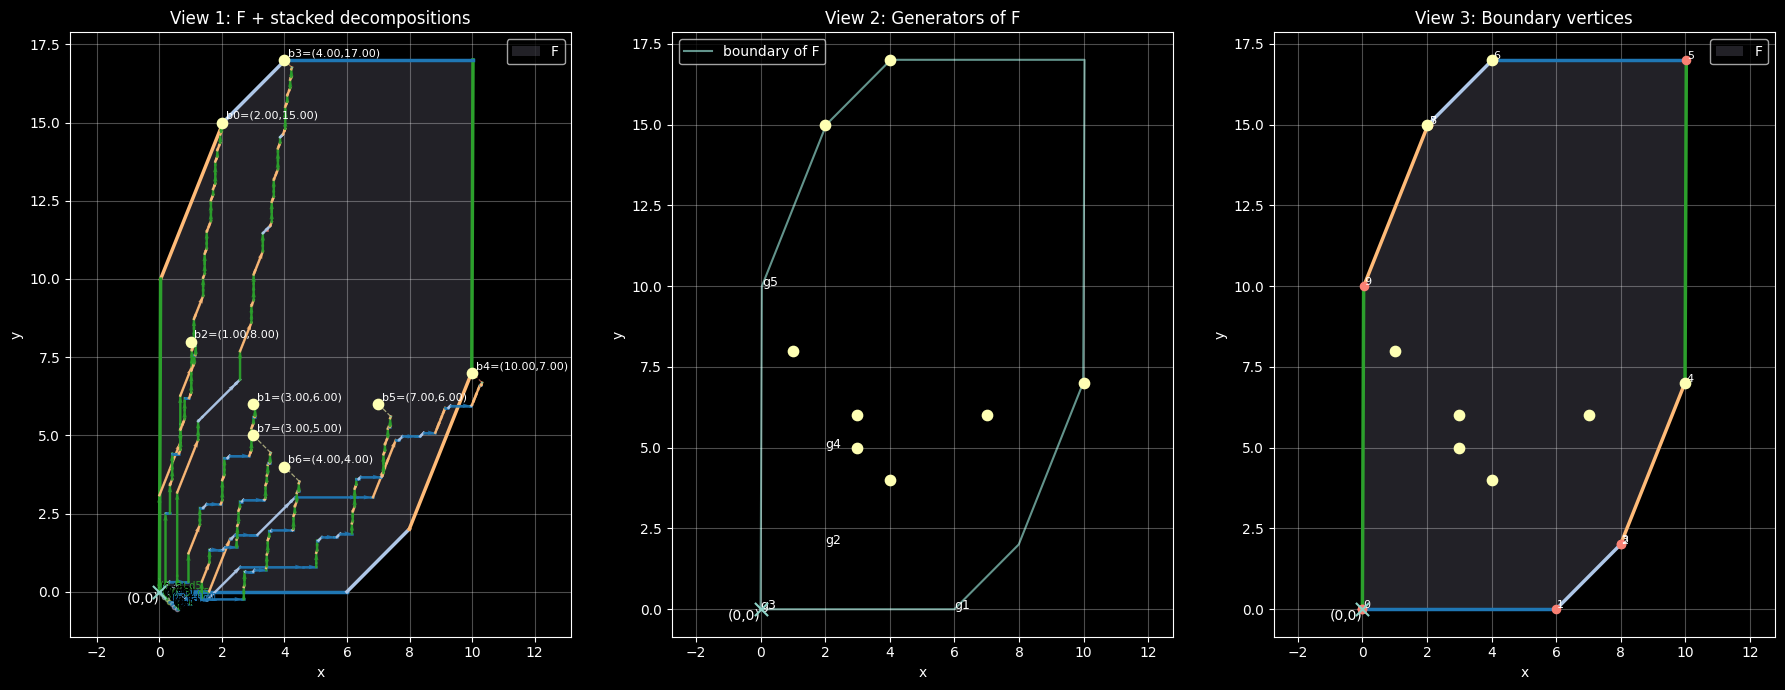

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# ---------------- LEFT: F + decompositions ----------------
ax = axes[0]
plot_targets(ax, b_points, "View 1: F + stacked decompositions")

boundary_colors = plot_colored_zonotope_boundary(ax, generators_F, linewidth=2.5)

draw_stacked_decomposition_fast(
    ax,
    used_by_point,
    b_points,
    color_map=color_map,
    dir_index_map=dir_index_map,
    point_offset_scale=0.08,
    show_segment_labels=True,
    max_segment_labels_per_point=4,
    show_connector=True,
)
ax.legend()

# ---------------- MIDDLE: generators of F ----------------
ax = axes[1]
plot_targets(ax, b_points, "View 2: Generators of F", label_points=False)

origin = np.zeros(2)
for j, g in enumerate(generators_F, start=1):
    ax.quiver(
        origin[0], origin[1], g[0], g[1],
        angles="xy", scale_units="xy", scale=1,
        width=0.004, alpha=0.9
    )
    ax.text(g[0], g[1], f"g{j}", fontsize=9)

if len(F_boundary) >= 2:
    Fx, Fy = zip(*F_boundary)
    ax.plot(Fx, Fy, linewidth=1.5, alpha=0.7, label="boundary of F", zorder=1)

ax.legend()

# ---------------- RIGHT: boundary vertices ----------------
ax = axes[2]
plot_targets(ax, b_points, "View 3: Boundary vertices", label_points=False)

plot_colored_zonotope_boundary(ax, generators_F, linewidth=2.5)

if len(F_boundary) >= 2:
    Fx, Fy = zip(*F_boundary)
    ax.scatter(Fx, Fy, s=35, zorder=3)

    for k, (x, y) in enumerate(F_boundary[:-1]):
        ax.text(x + 0.03, y + 0.03, str(k), fontsize=8)

ax.legend()

plt.tight_layout()
plt.show()

### Output Debugging

In [51]:
print("=" * 80)
print("OPTIMAL MONOTONE SOLUTION")
print("=" * 80)
print(f"Total cost = {best_solution['cost']:.6f}")
print()

print("Direction classes from active groups:")
for j, cls in enumerate(direction_classes, start=1):
    d = cls["direction"]
    lam = cls["total_length"]
    print(
        f"  d{j:2d}: direction=({d[0]:.6f}, {d[1]:.6f}), "
        f"angle={angle_deg(d):7.3f} deg, total_length={lam:.6f}"
    )
print()

print("Generators of F after explicit parallel merging:")
for j, g in enumerate(generators_F, start=1):
    d = g / np.linalg.norm(g)
    print(
        f"  g{j:2d}: generator=({g[0]:.6f}, {g[1]:.6f}), "
        f"length={np.linalg.norm(g):.6f}, angle={angle_deg(d):7.3f} deg"
    )
print()

print("Boundary edge directions actually present:")
for j, d in enumerate(boundary_dirs, start=1):
    print(
        f"  e{j:2d}: direction=({d[0]:.6f}, {d[1]:.6f}), "
        f"angle={angle_deg(d):7.3f} deg"
    )
print()

num_edges = len(F_boundary) - 1 if len(F_boundary) >= 2 else 0

print("=" * 80)
print("COUNTS")
print("=" * 80)
print(f"Number of direction classes from solution      = {len(direction_classes)}")
print(f"Number of generators after parallel merge      = {len(generators_F)}")
print(f"Number of undirected boundary edge directions  = {len(boundary_dirs)}")
print(f"Number of boundary edges                       = {num_edges}")
print(f"Expected number of edges if all generators distinct = {2 * len(generators_F)}")
print()

print("=" * 80)
print("ACTIVE GROUPS")
print("=" * 80)
for item in active_groups:
    S = tuple(item["group"])
    v = np.array(item["vector"], dtype=float)
    length = np.linalg.norm(v)
    if length <= 1e-4:
        continue

    d_idx = dir_index_map.get(S, "?")
    print(
        f"group {S}: tau=({v[0]:.6f}, {v[1]:.6f}), "
        f"length={length:.6f}, direction class=d{d_idx}"
    )

OPTIMAL MONOTONE SOLUTION
Total cost = 24.218064

Direction classes from active groups:
  d 1: direction=(1.000000, 0.000000), angle=  0.000 deg, total_length=5.998280
  d 2: direction=(0.705078, 0.709130), angle= 45.164 deg, total_length=2.827423
  d 3: direction=(0.406798, 0.913518), angle= 65.996 deg, total_length=0.000937
  d 4: direction=(0.370341, 0.928896), angle= 68.263 deg, total_length=5.389977
  d 5: direction=(0.003974, 0.999992), angle= 89.772 deg, total_length=9.995658

Generators of F after explicit parallel merging:
  g 1: generator=(5.998280, 0.000000), length=5.998280, angle=  0.000 deg
  g 2: generator=(1.993554, 2.005009), length=2.827423, angle= 45.164 deg
  g 3: generator=(0.000381, 0.000856), length=0.000937, angle= 65.996 deg
  g 4: generator=(1.996130, 5.006727), length=5.389977, angle= 68.263 deg
  g 5: generator=(0.039718, 9.995579), length=9.995658, angle= 89.772 deg

Boundary edge directions actually present:
  e 1: direction=(1.000000, 0.000000), angle=  0